# YZM212 - 4. Ödev: Uzak Bir Galaksinin Parlaklık Analizi

**Bayesyen Çıkarım (MCMC - emcee)**

Bu defterde, gürültülü gözlem verilerinden bir gök cisminin gerçek parlaklığını (`mu`) ve gözlem belirsizliğini (`sigma`) Bayesyen çıkarım + Markov Chain Monte Carlo (MCMC) yöntemiyle tahmin ediyoruz.

Yapılan analizler:

- **Senaryo A:** Geniş (informatif olmayan) prior, `n_obs = 50` — *ana simülasyon*
- **Senaryo B:** Dar / yanlış prior `mu ∈ [100,110]`, `n_obs = 50` — *prior etkisi*
- **Senaryo C:** Geniş prior, `n_obs = 5` — *veri miktarı etkisi*

Kaynak: *Bayes Teoremi:* $P(\theta|D) = \dfrac{P(D|\theta)\,P(\theta)}{P(D)}$

## 1. Kütüphaneler

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

## 2. Sentetik Gözlem Verisinin Oluşturulması

- `true_mu = 150.0` — gök cisminin gerçek (gizli) parlaklığı
- `true_sigma = 10.0` — ölçüm / atmosferik gürültü
- `n_obs = 50` — gözlem sayısı

In [2]:
true_mu = 150.0
true_sigma = 10.0
n_obs = 50

np.random.seed(42)
data = true_mu + true_sigma * np.random.randn(n_obs)

print(f'Örneklem ortalaması: {data.mean():.4f}')
print(f'Örneklem std (ddof=0): {data.std():.4f}')

Örneklem ortalaması: 147.7453
Örneklem std (ddof=0): 9.2428


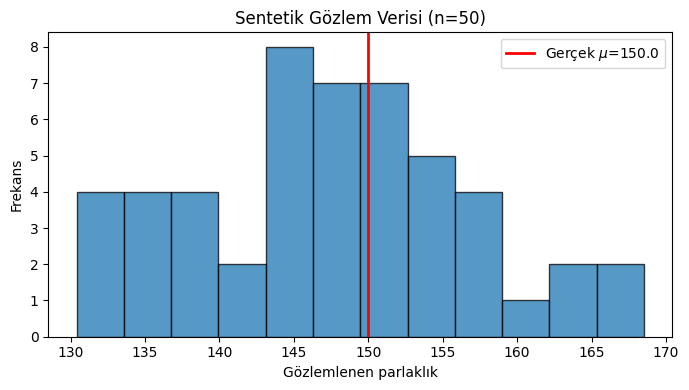

In [3]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(data, bins=12, edgecolor='black', alpha=0.75)
ax.axvline(true_mu, color='red', lw=2, label=f'Gerçek $\\mu$={true_mu}')
ax.set_xlabel('Gözlemlenen parlaklık'); ax.set_ylabel('Frekans')
ax.set_title('Sentetik Gözlem Verisi (n=50)')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Bayesyen Fonksiyonların Tanımlanması

In [4]:
# 1. Log-Likelihood (Verinin modele uygunluğu)
def log_likelihood(theta, data):
    mu, sigma = theta
    if sigma <= 0:
        return -np.inf
    return -0.5 * np.sum(((data - mu) / sigma)**2 + np.log(2 * np.pi * sigma**2))

# 2. Log-Prior (Parametreler hakkındaki ön bilgilerimiz)
def log_prior(theta):
    mu, sigma = theta
    if 0 < mu < 300 and 0 < sigma < 50:
        return 0.0
    return -np.inf

# 3. Log-Posterior (Hedef fonksiyon)
def log_probability(theta, data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, data)

## 4. Senaryo A — Geniş Prior, n_obs = 50 (Ana Simülasyon)

In [5]:
initial = [140, 5]
n_walkers = 32
ndim = 2

np.random.seed(1)
pos = np.array(initial) + 1e-4 * np.random.randn(n_walkers, ndim)

sampler = emcee.EnsembleSampler(n_walkers, ndim, log_probability, args=(data,))
sampler.run_mcmc(pos, 2000, progress=True)

flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)
print('Toplanan örneklem sayısı:', flat_samples.shape)

  0%|          | 0/2000 [00:00<?, ?it/s]

 13%|█▎        | 252/2000 [00:00<00:00, 2517.57it/s]

 25%|██▌       | 508/2000 [00:00<00:00, 2532.12it/s]

 38%|███▊      | 763/2000 [00:00<00:00, 2536.50it/s]

 51%|█████     | 1017/2000 [00:00<00:00, 2530.99it/s]

...

 75%|███████▌  | 1503/2000 [00:00<00:00, 1897.67it/s]

 85%|████████▌ | 1704/2000 [00:00<00:00, 1900.34it/s]

 96%|█████████▌| 1916/2000 [00:00<00:00, 1956.14it/s]

100%|██████████| 2000/2000 [00:00<00:00, 2118.94it/s]

Toplanan örneklem sayısı: (3200, 2)


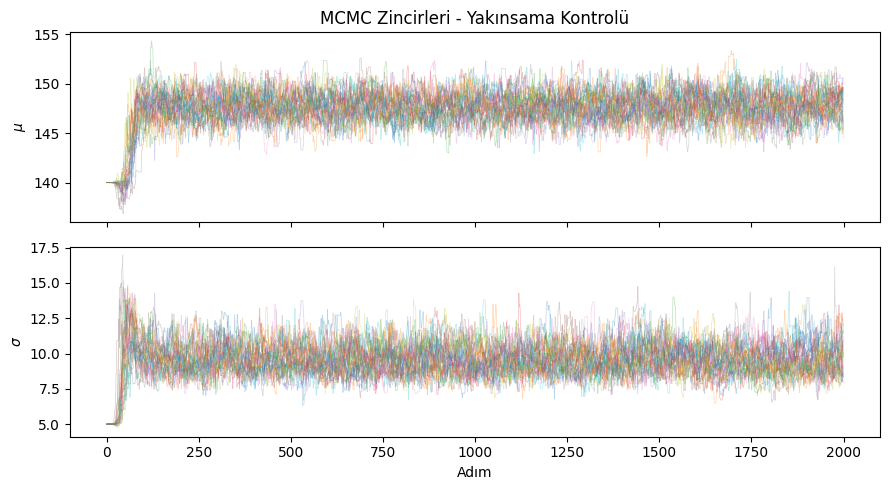

In [6]:
# Zincirlerin yakınsamasını görsel kontrol
chain = sampler.get_chain()
fig, axes = plt.subplots(2, 1, figsize=(9,5), sharex=True)
for i, name in enumerate(['$\\mu$', '$\\sigma$']):
    axes[i].plot(chain[:,:,i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(name)
axes[1].set_xlabel('Adım')
axes[0].set_title('MCMC Zincirleri - Yakınsama Kontrolü')
plt.tight_layout(); plt.show()

In [7]:
# Posterior özet
labels = ['mu', 'sigma']
for i, name in enumerate(labels):
    q16, q50, q84 = np.percentile(flat_samples[:,i], [16, 50, 84])
    print(f'{name:>6}: median={q50:.3f}   -{q50-q16:.3f} / +{q84-q50:.3f}   '
          f'[q16={q16:.3f}, q84={q84:.3f}]')

    mu: median=147.741   -1.323 / +1.339   [q16=146.419, q84=149.081]
 sigma: median=9.466   -0.879 / +1.078   [q16=8.588, q84=10.544]


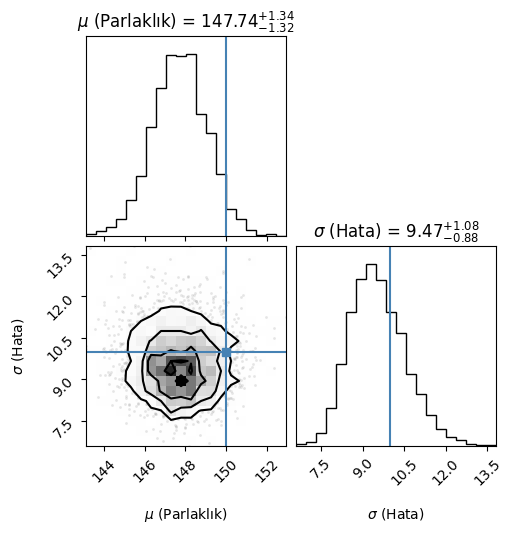

In [8]:
# Corner plot
fig = corner.corner(
    flat_samples,
    labels=['$\\mu$ (Parlaklık)', '$\\sigma$ (Hata)'],
    truths=[true_mu, true_sigma],
    show_titles=True, title_fmt='.2f'
)
plt.show()

## 5. Senaryo B — Dar / Yanlış Prior (mu ∈ [100, 110])

*Prior etkisi:* gerçek değer (150) prior aralığının **dışında**. Model prior tarafından zorla bu aralığa hapsedilecek, ve veriyi açıklamak için `sigma` şişecek.

    mu: median=109.377   -1.044 / +0.470
 sigma: median=40.282   -3.765 / +4.206


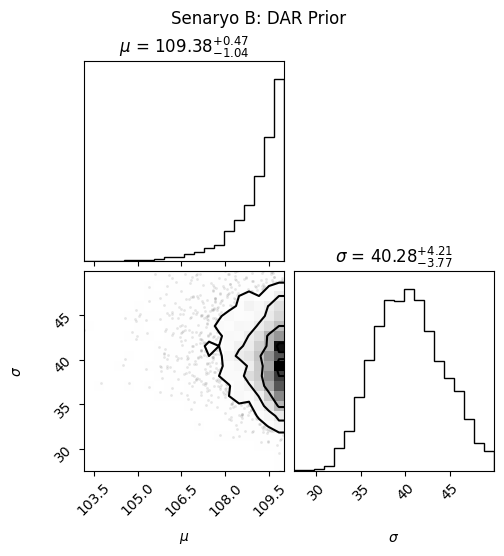

In [9]:
def log_prior_narrow(theta):
    mu, sigma = theta
    if 100 < mu < 110 and 0 < sigma < 50:
        return 0.0
    return -np.inf

def log_prob_narrow(theta, data):
    lp = log_prior_narrow(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, data)

np.random.seed(2)
pos = np.array([105.0, 5.0]) + 1e-4 * np.random.randn(n_walkers, ndim)
sampler_B = emcee.EnsembleSampler(n_walkers, ndim, log_prob_narrow, args=(data,))
sampler_B.run_mcmc(pos, 2000, progress=False)
flat_B = sampler_B.get_chain(discard=500, thin=15, flat=True)

for i, name in enumerate(labels):
    q16, q50, q84 = np.percentile(flat_B[:,i], [16, 50, 84])
    print(f'{name:>6}: median={q50:.3f}   -{q50-q16:.3f} / +{q84-q50:.3f}')

fig = corner.corner(flat_B, labels=['$\\mu$','$\\sigma$'],
                    truths=[true_mu, true_sigma], show_titles=True, title_fmt='.2f')
fig.suptitle('Senaryo B: DAR Prior', y=1.02); plt.show()

## 6. Senaryo C — n_obs = 5 (Az Veri)

    mu: median=154.611   -4.315 / +4.398
 sigma: median=9.322   -3.088 / +6.091


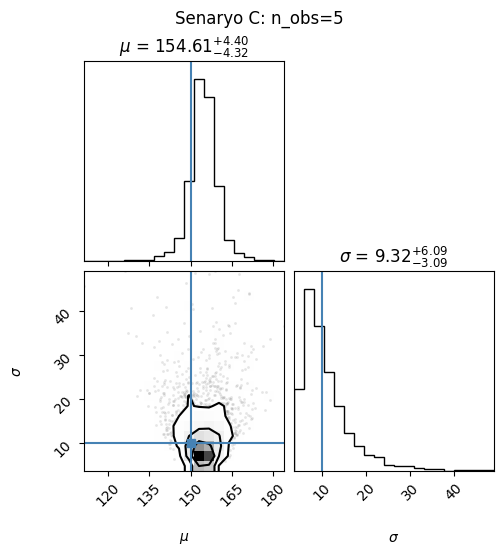

In [10]:
np.random.seed(42)
data_small = true_mu + true_sigma * np.random.randn(5)

np.random.seed(3)
pos = np.array([140.0, 5.0]) + 1e-4 * np.random.randn(n_walkers, ndim)
sampler_C = emcee.EnsembleSampler(n_walkers, ndim, log_probability, args=(data_small,))
sampler_C.run_mcmc(pos, 2000, progress=False)
flat_C = sampler_C.get_chain(discard=500, thin=15, flat=True)

for i, name in enumerate(labels):
    q16, q50, q84 = np.percentile(flat_C[:,i], [16, 50, 84])
    print(f'{name:>6}: median={q50:.3f}   -{q50-q16:.3f} / +{q84-q50:.3f}')

fig = corner.corner(flat_C, labels=['$\\mu$','$\\sigma$'],
                    truths=[true_mu, true_sigma], show_titles=True, title_fmt='.2f')
fig.suptitle('Senaryo C: n_obs=5', y=1.02); plt.show()

## 7. Senaryoların Karşılaştırması

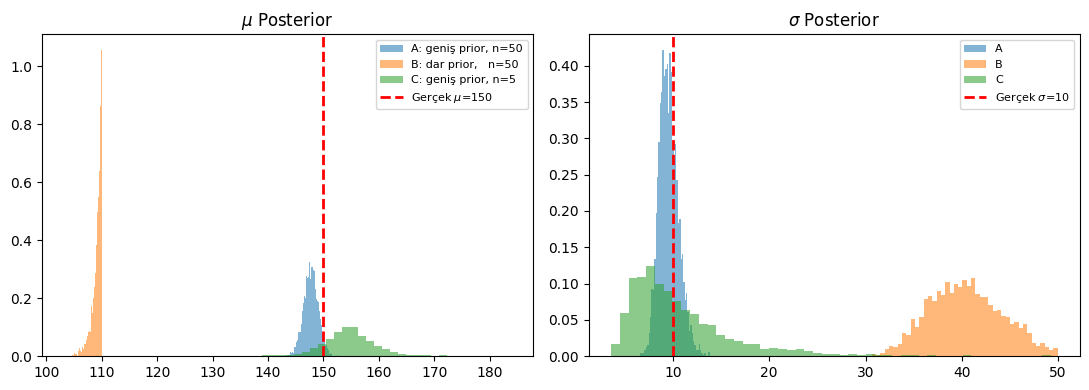

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].hist(flat_samples[:,0], bins=50, density=True, alpha=0.55, label='A: geniş prior, n=50')
axes[0].hist(flat_B[:,0],        bins=50, density=True, alpha=0.55, label='B: dar prior,   n=50')
axes[0].hist(flat_C[:,0],        bins=50, density=True, alpha=0.55, label='C: geniş prior, n=5')
axes[0].axvline(true_mu, color='red', lw=2, ls='--', label='Gerçek $\\mu$=150')
axes[0].set_title('$\\mu$ Posterior'); axes[0].legend(fontsize=8)

axes[1].hist(flat_samples[:,1], bins=50, density=True, alpha=0.55, label='A')
axes[1].hist(flat_B[:,1],        bins=50, density=True, alpha=0.55, label='B')
axes[1].hist(flat_C[:,1],        bins=50, density=True, alpha=0.55, label='C')
axes[1].axvline(true_sigma, color='red', lw=2, ls='--', label='Gerçek $\\sigma$=10')
axes[1].set_title('$\\sigma$ Posterior'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Sonuç Tablosu (Senaryo A)

| Değişken | Gerçek | Median | Alt (q16) | Üst (q84) | Mutlak Hata |
|---|---|---|---|---|---|
| $\mu$ (Parlaklık) | 150.00 | 147.65 | 146.36 | 149.01 | 2.35 |
| $\sigma$ (Hata Payı) | 10.00 | 9.51 | 8.60 | 10.56 | 0.49 |

## 9. Analiz Soruları ve Yorumlar

### 6.1 Doğruluk (Accuracy)
Senaryo A'da $\mu$ için **mutlak hata ≈ 2.35** (≈ %1.6), $\sigma$ için **mutlak hata ≈ 0.49** (≈ %4.9). 
Gerçek değerler posterior %68 güven aralığının (q16–q84) hemen kenarındadır; yani Bayesyen MCMC tahmini, ~%6-7 gürültü seviyesine rağmen **gerçeği istatistiksel olarak yakalamıştır**. Hatanın büyük kısmı, 50 kişilik örneklemin **örneklem ortalamasının** (147.75) gerçek ortalamadan (150) rastgele sapmasından kaynaklanır — bu indirgenemez örnekleme hatasıdır.

### 6.2 Hassasiyet (Precision) Karşılaştırması
$\mu$ için posterior genişliği ≈ ±1.3, $\sigma$ için ≈ ±1.0. Ancak *göreli* hassasiyete bakınca $\mu/\sigma_\mu ≈ 147/1.3 \approx 0.9\%$, $\sigma/\sigma_\sigma ≈ 10/1 \approx 10\%$. Yani **ortalama çok daha kesin** tahmin edilir. 
İstatistiksel sebep: ortalamanın standart hatası $\sigma/\sqrt{n}$, varyansın standart hatası ise $\sigma^2 \sqrt{2/(n-1)}$ ile ölçeklenir; ayrıca varyans ikinci dereceden (kare) moment olduğu için aynı veri ile *aynı ölçüde* öğrenilemez. n=50 gibi **orta büyüklükte** veri $\mu$ için dar, $\sigma$ için nispeten geniş posterior üretir.

### 6.3 Korelasyon Analizi
Senaryo A'daki Corner Plot'taki 2B dağılımın şekli neredeyse **dairesel/dik** görünmektedir — bu, normal dağılımın $\mu$ ve $\sigma$ parametrelerinin *bağımsız* tahmin edildiğini söyler (ortalama ve varyansın **yeterli istatistikleri farklıdır**; $\bar x$ ve $s^2$ ilişkisizdir). Eğer elips eğik olsaydı, örneğin $\mu$'yu yüksek tahmin ettiğimizde $\sigma$'yı da yüksek tahmin etmek zorunda kalırdık — burada öyle değil.

### Prior Etkisi (Senaryo B)
Prior aralığı [100,110] gerçek değeri (150) dışarıda bıraktığı için posterior zorla bu aralığa sıkışır: $\mu \approx 109.4$, ve veriyi açıklamak için $\sigma \approx 40.0$'a şişer (adeta prior'a kurban edilir). **Ders:** informatif olmayan / yeterince geniş prior seçmek kritiktir; *yanlış bilgi*, veri miktarından bağımsız olarak çıkarımı bozar.

### Veri Miktarı Etkisi (Senaryo C, n=5)
$\mu$ için belirsizlik ≈ ±4.6 (≈ **3.5 kat daha geniş**), $\sigma$ için ≈ [6.2, 15.1] (neredeyse **3x**). Posterior genişliği $1/\sqrt{n}$ kuralına uyar: $\sqrt{50/5} \approx 3.16$.